In [1]:
import pandas as pd


In [2]:
df=pd.read_csv("clean_netflix_dataset.csv")

In [4]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8709 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8807 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.8 MB


In [6]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

In [7]:
df.shape

(8807, 12)

In [8]:
print("Mean:", df["release_year"].mean())

Mean: 2014.1801975701146


In [9]:
print("Median:", df["release_year"].median())

Median: 2017.0


In [10]:
print("Mode:", df["release_year"].mode())

Mode: 0    2018
Name: release_year, dtype: int64


In [11]:
print("standard deviation:", df["release_year"].std())

standard deviation: 8.819312130833966


In [12]:
print("variance:", df["release_year"].var())

variance: 77.78026646107516


In [13]:
import matplotlib.pyplot as plt

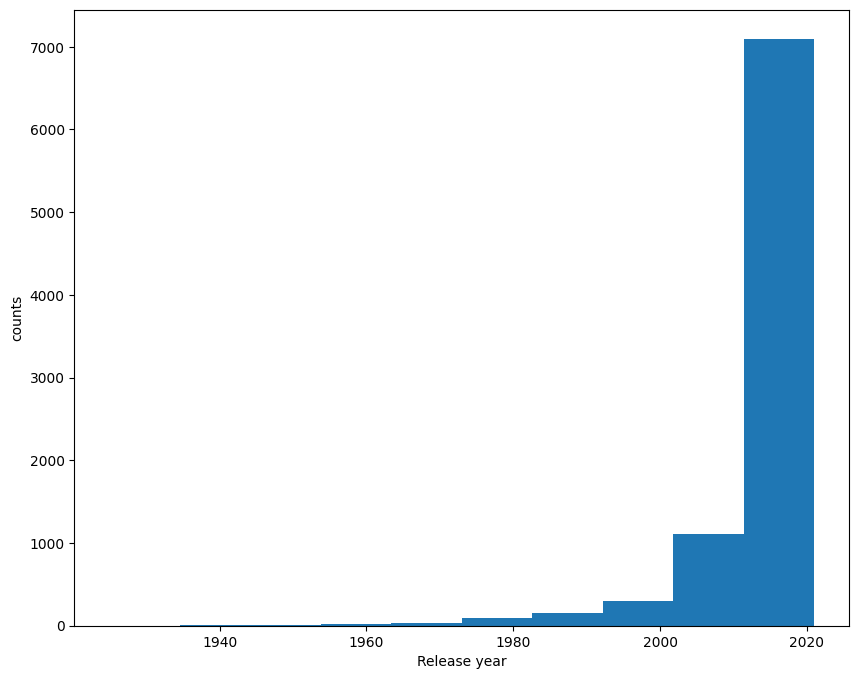

In [14]:
plt.figure(figsize=(10,8))
plt.hist(df["release_year"])
plt.xlabel("Release year")
plt.ylabel("counts")
plt.show()

In [15]:
from scipy.stats import ttest_ind

In [16]:
#alg kiya h dono ko movies and tvshowsko
movies = df[df["type"] == "Movie"]["release_year"]

tvshows = df[df["type"] == "TV Show"]["release_year"]

In [17]:
#perform t_test
t_test,p_value=ttest_ind(movies,tvshows)

In [18]:
print("t_stats:",t_test)

t_stats: -17.339416624102576


In [19]:
print("p_value:",p_value)

p_value: 2.965941136090255e-66


In [20]:
if p_value < 0.05:
    print("Reject Null Hypothesis")

else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


In [21]:
if p_value < 0.05:
    print("Movies and TV Shows differ significantly in release year.")

else:
    print("No significant difference found.")

Movies and TV Shows differ significantly in release year.


In [22]:
from scipy import stats

In [23]:
release_year=df["release_year"]

In [24]:
release_year

0       2020
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2007
8803    2018
8804    2009
8805    2006
8806    2015
Name: release_year, Length: 8807, dtype: int64

In [26]:
mean=release_year.mean()

In [27]:
mean

np.float64(2014.1801975701146)

In [28]:
ci=stats.t.interval(
    confidence=0.95,
    df=len(release_year)-1,
    loc=mean,
    scale=stats.sem(release_year)

    
)

In [29]:
print("mean:",mean)
print("95%:",ci)

mean: 2014.1801975701146
95%: (np.float64(2013.995981080211), np.float64(2014.3644140600181))
